In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housingdata-aspdc/HousingData.csv


In [46]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split


#import csv file
data= pd.read_csv("/kaggle/input/housingdata-aspdc/HousingData.csv")



In [47]:
data.head(10)  # first 10 rows

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
0,Premium,2.0,1.0,1.0,1.0,2.0,NaN,15.0,1260.0,16072000.0
1,Luxury,4.0,3.0,2.0,1.0,3.0,3.0,NaN,2400.0,32674000.0
2,Luxury,3.0,2.0,NaN,1.0,3.0,1.0,0.0,2060.0,29660000.0
3,Ultra Luxury,6.0,5.0,3.0,2.0,5.0,2.0,2.0,3880.0,71862000.0
4,Economy,1.0,1.0,0.0,NaN,1.0,1.0,-1.0,310.0,3485000.0
5,Economy,1.0,NaN,0.0,1.0,1.0,1.0,2.0,330.0,3326000.0
6,Luxury,3.0,NaN,2.0,1.0,3.0,2.0,-2.0,1880.0,18459000.0
7,Premium,2.0,NaN,1.0,1.0,2.0,2.0,5.0,1230.0,12957000.0
8,Premium,3.0,2.0,NaN,1.0,2.0,1.0,10.0,NaN,21836000.0
9,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,360.0,3151000.0


In [48]:
data.info(10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Category             953 non-null    object 
 1   Bedrooms             970 non-null    float64
 2   Bathrooms            891 non-null    float64
 3   SUVs                 932 non-null    float64
 4   Cars                 929 non-null    float64
 5   Garages              942 non-null    float64
 6   Domestic Help Rooms  949 non-null    float64
 7   Age of House         901 non-null    float64
 8   House Area           933 non-null    float64
 9   Price                917 non-null    float64
dtypes: float64(9), object(1)
memory usage: 78.3+ KB


In [49]:

data.info  #fatch the null value of table
data.describe  #statical value

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


<bound method NDFrame.describe of          Category  Bedrooms  Bathrooms  SUVs  Cars  Garages  \
0         Premium       2.0        1.0   1.0   1.0      2.0   
1          Luxury       4.0        3.0   2.0   1.0      3.0   
2          Luxury       3.0        2.0   NaN   1.0      3.0   
3    Ultra Luxury       6.0        5.0   3.0   2.0      5.0   
4         Economy       1.0        1.0   0.0   NaN      1.0   
..            ...       ...        ...   ...   ...      ...   
995       Economy       1.0        1.0   0.0   1.0      1.0   
996        Luxury       4.0        3.0   1.0   1.0      2.0   
997        Luxury       4.0        3.0   2.0   1.0      3.0   
998       Premium       2.0        1.0   1.0   1.0      2.0   
999           NaN       1.0        1.0   0.0   1.0      1.0   

     Domestic Help Rooms  Age of House  House Area       Price  
0                    NaN          15.0      1260.0  16072000.0  
1                    3.0           NaN      2400.0  32674000.0  
2             

In [50]:
data['Age of House']=data['Age of House'].abs()
print('summry after correcting')
data['Age of House'].describe()

summry after correcting


count    901.000000
mean       4.648169
std        4.497094
min        0.000000
25%        1.000000
50%        2.000000
75%        8.000000
max       15.000000
Name: Age of House, dtype: float64

In [51]:
#check duplicate rows
duplicate_rows=data.duplicated().sum()
print("number of duplicates rows",duplicate_rows)

#remove duplicate rows
data.drop_duplicates(inplace=True)
print(f"no. of rows after removing duplicates {len(data)}")

number of duplicates rows 4
no. of rows after removing duplicates 996


In [52]:
#total count of missing values
missv_count=data.isnull().sum()
print("count of missing value per column")
print(missv_count[missv_count>0].sort_values(ascending=False))

count of missing value per column
Bathrooms              109
Age of House            99
Price                   80
Cars                    71
SUVs                    68
House Area              66
Garages                 58
Domestic Help Rooms     51
Category                47
Bedrooms                30
dtype: int64


In [53]:
#fill missing values in colums with median
num_cols = data.select_dtypes(include=np.number).columns

for col in num_cols:
    median_value=data[col].median()
    data[col].fillna(median_value , inplace=True)
    #inplace true means proceesing in column wise and false means rows

print("ALL the missing values with their respective meduan values ")

ALL the missing values with their respective meduan values 


/tmp/ipykernel_40/1489874318.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(median_value , inplace=True)


In [10]:
data.tail(10)

,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
990,Premium,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1230.0,15793000.0
991,Luxury,4.0,3.0,1.0,1.0,2.0,2.0,10.0,2400.0,47133000.0
992,Economy,1.0,2.0,0.0,1.0,1.0,1.0,2.0,390.0,4867000.0
993,Economy,1.0,1.0,0.0,1.0,1.0,1.0,12.0,330.0,16636500.0
994,Premium,2.0,1.0,1.0,1.0,2.0,1.0,2.0,1240.0,14700000.0
995,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,310.0,16636500.0
996,Luxury,4.0,3.0,1.0,1.0,2.0,3.0,1.0,2310.0,46762000.0
997,Luxury,4.0,3.0,2.0,1.0,3.0,2.0,0.0,2570.0,53195000.0
998,Premium,2.0,1.0,1.0,1.0,2.0,2.0,0.0,1220.0,17591000.0
999,NaN,1.0,1.0,0.0,1.0,1.0,1.0,2.0,380.0,4314000.0


In [54]:
#mode use when data is categories and 
#when outliers are very much use median ,when values near about in data use mean

mode_value = data['Category'].mode()[0]
data['Category'].fillna(mode_value , inplace = True)

print("ALL the missing values with their respective mode values ")
data.tail(10)

ALL the missing values with their respective mode values 


/tmp/ipykernel_40/819772903.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Category'].fillna(mode_value , inplace = True)


,Category,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
990,Premium,2.0,1.0,1.0,1.0,2.0,2.0,2.0,1230.0,15793000.0
991,Luxury,4.0,3.0,1.0,1.0,2.0,2.0,10.0,2400.0,47133000.0
992,Economy,1.0,2.0,0.0,1.0,1.0,1.0,2.0,390.0,4867000.0
993,Economy,1.0,1.0,0.0,1.0,1.0,1.0,12.0,330.0,16636500.0
994,Premium,2.0,1.0,1.0,1.0,2.0,1.0,2.0,1240.0,14700000.0
995,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,310.0,16636500.0
996,Luxury,4.0,3.0,1.0,1.0,2.0,3.0,1.0,2310.0,46762000.0
997,Luxury,4.0,3.0,2.0,1.0,3.0,2.0,0.0,2570.0,53195000.0
998,Premium,2.0,1.0,1.0,1.0,2.0,2.0,0.0,1220.0,17591000.0
999,Economy,1.0,1.0,0.0,1.0,1.0,1.0,2.0,380.0,4314000.0


In [55]:
total_missing_data = data.isnull().sum().sum()
print(f"Total number of missing vaues in the dataset : {total_missing_data}")


Total number of missing vaues in the dataset : 0


In [56]:
#converting datatypes from one to other 
cols_to_int = ['Bedrooms','Bathrooms', 'SUVs','Cars','Garages',
               'Age of House' , 'House Area' ,'Price']

for col in cols_to_int :
    data[col] = data[col].astype(int)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Category             996 non-null    object 
 1   Bedrooms             996 non-null    int64  
 2   Bathrooms            996 non-null    int64  
 3   SUVs                 996 non-null    int64  
 4   Cars                 996 non-null    int64  
 5   Garages              996 non-null    int64  
 6   Domestic Help Rooms  996 non-null    float64
 7   Age of House         996 non-null    int64  
 8   House Area           996 non-null    int64  
 9   Price                996 non-null    int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 85.6+ KB


In [57]:
import matplotlib.pyplot as plt 
import seaborn as sns
numeric_cols = data.select_dtypes(include = [np.number]).columns.tolist()
print(f"Numeric columns are : {numeric_cols}")

Numeric columns are : ['Bedrooms', 'Bathrooms', 'SUVs', 'Cars', 'Garages', 'Domestic Help Rooms', 'Age of House', 'House Area', 'Price']


In [58]:
target = "Price"

In [59]:
#num_data = data[numeric_cols].dropna().reset_index(inplace = True)

num_data = data[numeric_cols].dropna()
num_data.reset_index(inplace=True)


In [60]:
corr_data = num_data.corr(method = 'pearson')

print("\n Pearson correlation matrix (using Pandas) :")
display(corr_data.round(4))


 Pearson correlation matrix (using Pandas) :


,index,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price
index,1.0000,0.0371,0.0459,0.0242,0.0535,0.0416,0.0046,0.0169,0.0423,0.0511
Bedrooms,0.0371,1.0000,0.8064,0.8004,0.5356,0.8245,0.6978,0.0036,0.9357,0.8658
Bathrooms,0.0459,0.8064,1.0000,0.6176,0.4792,0.6637,0.5716,-0.0036,0.7808,0.7331
SUVs,0.0242,0.8004,0.6176,1.0000,0.3951,0.8561,0.6564,0.0250,0.8218,0.7601
Cars,0.0535,0.5356,0.4792,0.3951,1.0000,0.7106,0.4580,-0.0338,0.5858,0.5771
Garages,0.0416,0.8245,0.6637,0.8561,0.7106,1.0000,0.6781,0.0099,0.8648,0.8085
Domestic Help Rooms,0.0046,0.6978,0.5716,0.6564,0.4580,0.6781,1.0000,-0.0205,0.7324,0.6799
Age of House,0.0169,0.0036,-0.0036,0.0250,-0.0338,0.0099,-0.0205,1.0000,0.0132,0.0148
House Area,0.0423,0.9357,0.7808,0.8218,0.5858,0.8648,0.7324,0.0132,1.0000,0.8707
Price,0.0511,0.8658,0.7331,0.7601,0.5771,0.8085,0.6799,0.0148,0.8707,1.0000


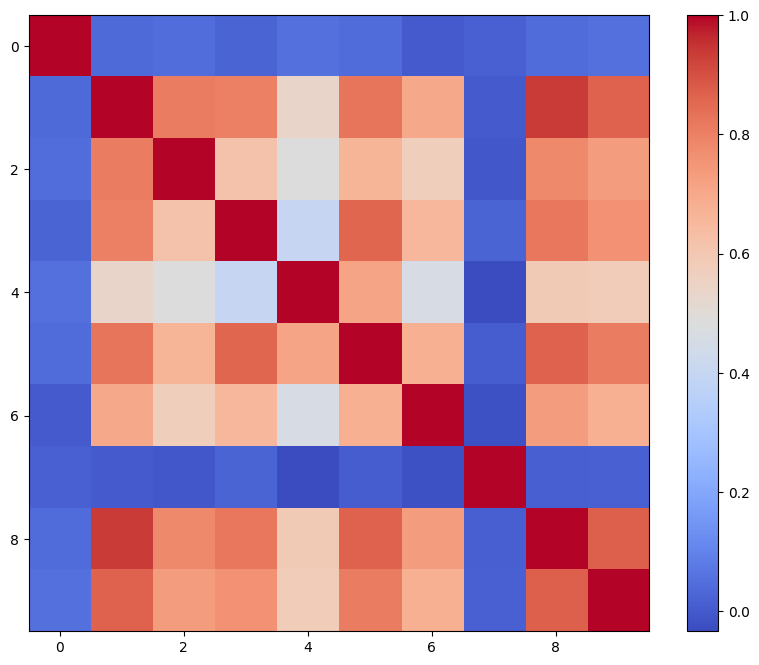

In [61]:
#correlation map 

plt.figure(figsize=(10,8))
plt.imshow(corr_data,aspect='auto',cmap="coolwarm")
plt.colorbar(label="")

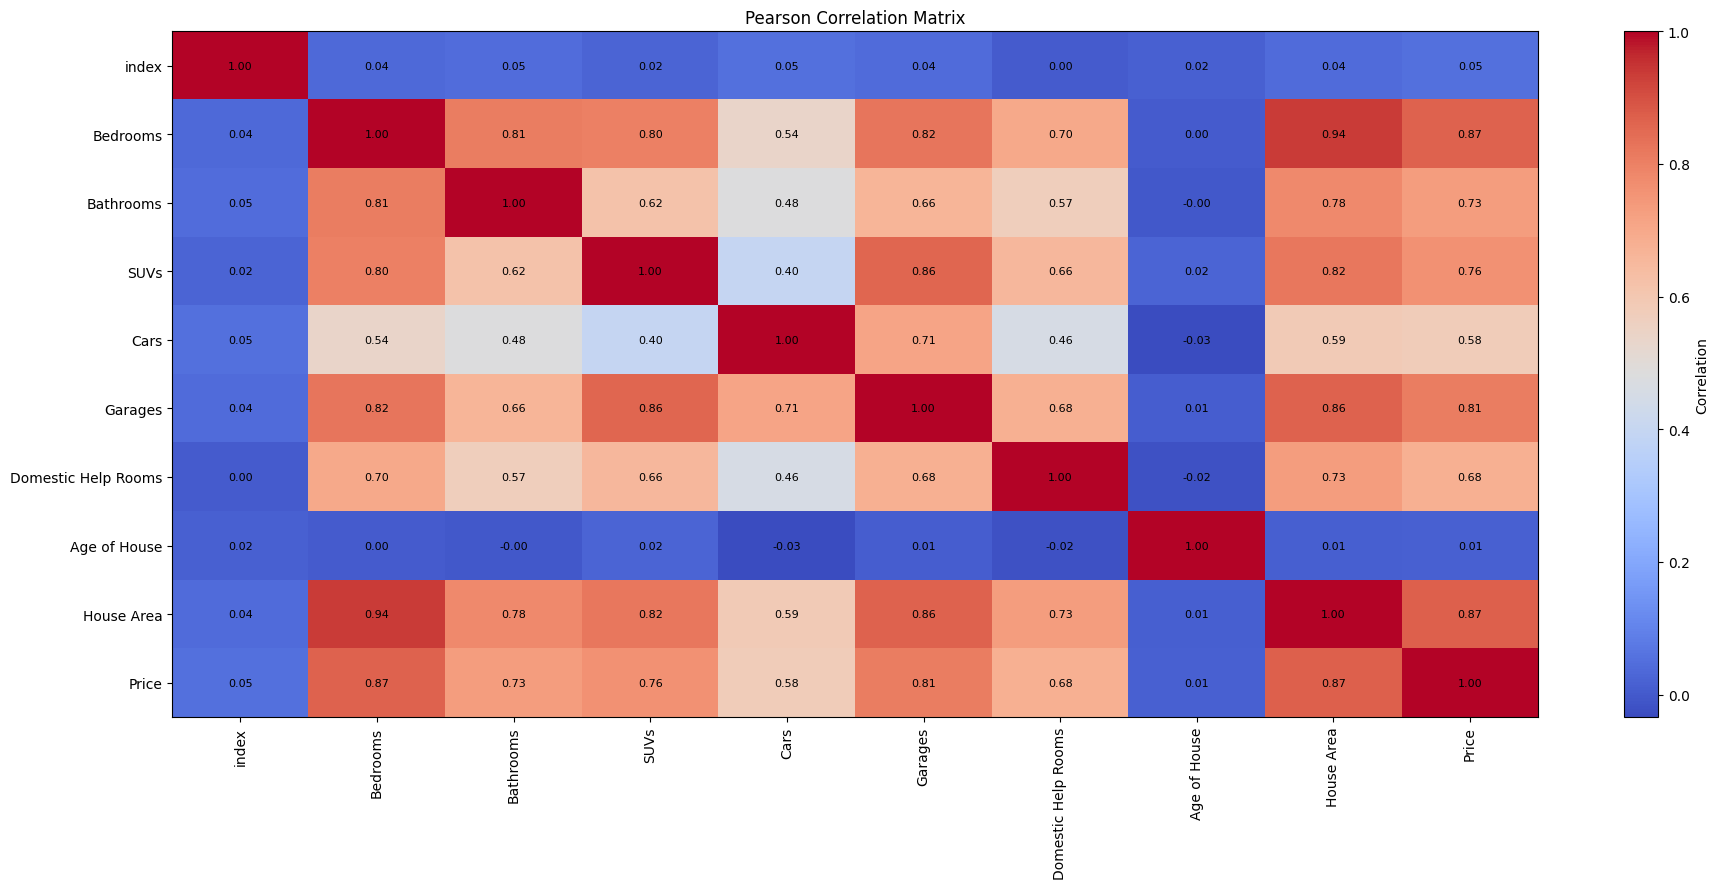

In [62]:
plt.figure(figsize=(19,9))
plt.imshow(corr_data, aspect='auto', cmap='coolwarm')
plt.colorbar(label="Correlation")
plt.title("Pearson Correlation Matrix")
plt.xticks(ticks=np.arange(len(num_data.columns)), labels=num_data.columns, rotation=90)
plt.yticks(ticks=np.arange(len(num_data.columns)), labels=num_data.columns)

# Annotate values
for i in range(len(num_data.columns)):
    for j in range(len(num_data.columns)):
        plt.text(j, i, f"{corr_data.iloc[i,j]:.2f}",
                 ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

In [63]:
print(data.columns.tolist())

['Category', 'Bedrooms', 'Bathrooms', 'SUVs', 'Cars', 'Garages', 'Domestic Help Rooms', 'Age of House', 'House Area', 'Price']


In [64]:
data.dtypes

Category                object
Bedrooms                 int64
Bathrooms                int64
SUVs                     int64
Cars                     int64
Garages                  int64
Domestic Help Rooms    float64
Age of House             int64
House Area               int64
Price                    int64
dtype: object

In [65]:
data = pd.get_dummies(data, columns=['Category'], drop_first=True)

data.head(5)

,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price,Category_Luxury,Category_Premium,Category_Ultra Luxury
0,2,1,1,1,2,1.0,15,1260,16072000,False,True,False
1,4,3,2,1,3,3.0,2,2400,32674000,True,False,False
2,3,2,1,1,3,1.0,0,2060,29660000,True,False,False
3,6,5,3,2,5,2.0,2,3880,71862000,False,False,True
4,1,1,0,1,1,1.0,1,310,3485000,False,False,False


In [66]:
dummy_cols = [
    'Category_Luxury',
    'Category_Premium',
    'Category_Ultra Luxury'
]

data[dummy_cols] = data[dummy_cols].astype(int)
data.head(5)

,Bedrooms,Bathrooms,SUVs,Cars,Garages,Domestic Help Rooms,Age of House,House Area,Price,Category_Luxury,Category_Premium,Category_Ultra Luxury
0,2,1,1,1,2,1.0,15,1260,16072000,0,1,0
1,4,3,2,1,3,3.0,2,2400,32674000,1,0,0
2,3,2,1,1,3,1.0,0,2060,29660000,1,0,0
3,6,5,3,2,5,2.0,2,3880,71862000,0,0,1
4,1,1,0,1,1,1.0,1,310,3485000,0,0,0


In [68]:
X = data.drop('Price', axis=1)
y = data['Price']

In [70]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [72]:
print("Intercept:", lr_model.intercept_)

Intercept: -4929525.557275955


In [73]:
y_pred = lr_model.predict(X_test)

#print(y_pred[:10])

In [74]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

#comparison.head(10)

In [75]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 5190872.984638787
MSE : 69518640778029.46
RMSE : 8337783.9248825265
R2 Score : 0.8432426748003585


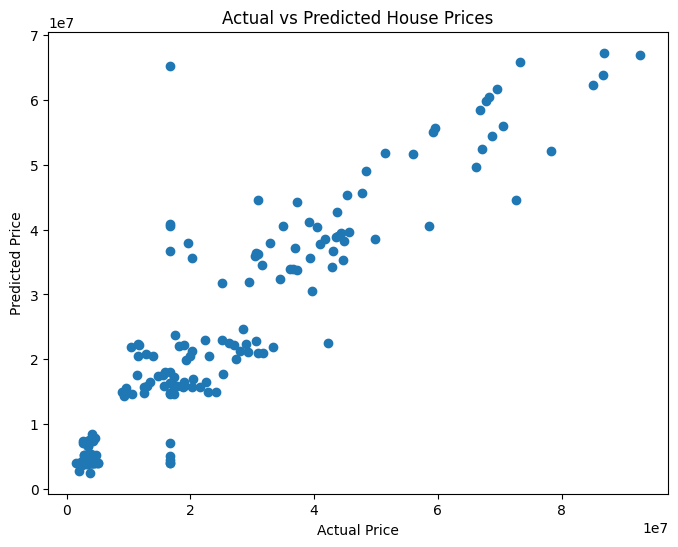

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [77]:
new_house = [[
    3,      # Bedrooms
    2,      # Bathrooms
    1,      # SUVs
    1,      # Cars
    2,      # Garages
    1,      # Domestic Help Rooms
    5,      # Age of House
    2000,   # House Area
    1,      # Category_Luxury
    0,      # Category_Premium
    0       # Category_Ultra Luxury
]]

predicted_price = lr_model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 29937238.1715389


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
